<a href="https://colab.research.google.com/github/nehabellale-boop/ANNDL_Project/blob/main/Neha_Bellale_A_76_(TA_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# STEP 1: Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


# Load the dataset
df = pd.read_csv('/content/stock_dataset.csv')

print(df.head())
print(df.columns)

         Date       Close
0  2019-01-01  152.008062
1  2019-01-02  149.740751
2  2019-01-03  150.436105
3  2019-01-04  151.584164
4  2019-01-07  153.454726
Index(['Date', 'Close'], dtype='object')


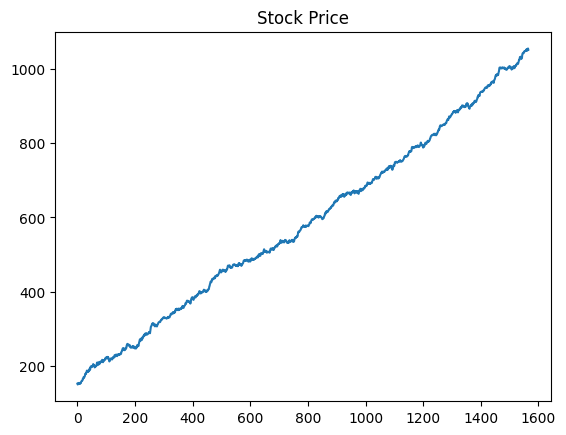

In [6]:
# STEP 3: Data Preprocessing
# Convert Date column (adjust if name is different)
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')

# Select Close price (adjust if needed)
if 'Close' in df.columns:
    data = df[['Close']].values
elif 'close' in df.columns:
    data = df[['close']].values
else:
    raise Exception("No Close column found")

# Plot original data
plt.plot(data)
plt.title("Stock Price")
plt.show()

# Normalize data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [7]:
# STEP 4: Create Sequences

X = []
y = []

time_step = 60

for i in range(time_step, len(scaled_data)):
    X.append(scaled_data[i-time_step:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

# Reshape for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

# STEP 5: Train-Test Split
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]



In [8]:
# STEP 6: Build LSTM Model

model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(50))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# STEP 7: Train Model
model.fit(X_train, y_train, epochs=20, batch_size=32)


# STEP 8: Prediction
predictions = model.predict(X_test)

# Inverse scaling
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))


Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.0129
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0025
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0017
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 0.0018
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0016
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0016
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0016
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0014
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0014
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0013
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0013
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0013
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0014
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0013
Epoch 15/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0012
Epoc

In [10]:
# STEP 9: Evaluation

mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)


MAE: 6.5456353682430715
RMSE: 8.190752142984216
MAPE: 0.6714643695271107


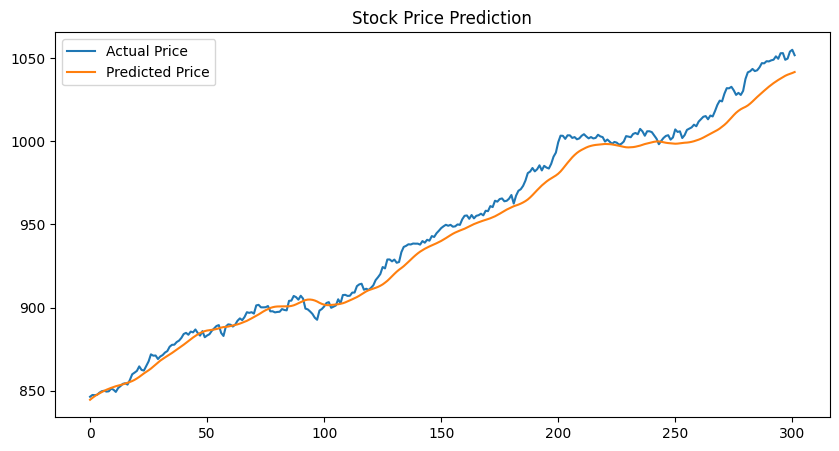

In [11]:
# STEP 10: Visualization

plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("Stock Price Prediction")
plt.show()